---
# 1) Dependency Installation
---

In [17]:
#!pip install qiskit qiskit-aer qiskit-ibm-runtime numpy scipy matplotlib seaborn pandas ipywidgets pylatexenc tqdm
# Uncomment to install the dependencies

---
# 2) Algorithm implementation and utilities
---

## 2.1) Imports

In [19]:
# Standard libraries
import os                             # File management
import time                           # Time measurement utilities
from dotenv import load_dotenv        # Environment variables management

# Scientific computing
import numpy as np                    # Numerical computations
import matplotlib.pyplot as plt       # Plotting and visualization

# Qiskit core components
from qiskit import QuantumCircuit     # Quantum circuit creation
from qiskit import transpile          # Circuit compilation for backend

# Qiskit circuit libraries
from qiskit.circuit.library import QFTGate   # Built-in Quantum Fourier Transform gate

# Transpilation utilities
from qiskit.transpiler.preset_passmanagers import (
    generate_preset_pass_manager      # Predefined optimization pipelines
)

# Simulation (Aer)
from qiskit_aer import AerSimulator   # High-performance simulator backend

# Noise modeling
from qiskit_aer.noise import NoiseModel          # Noise model container
from qiskit_aer.noise import depolarizing_error  # Depolarizing noise channel

# Visualization tools
from qiskit.visualization import (
    plot_histogram,              # Measurement results histogram
    plot_bloch_multivector       # Bloch sphere representation of quantum states
)

# IBM Quantum Runtime
from qiskit_ibm_runtime import (
    QiskitRuntimeService,        # Access IBM Quantum services
    SamplerV2                    # Efficient circuit sampling primitive
)

## 2.2) QTF Implementation

In [3]:
def qft(qc, n):
    for i in range(n):
        # Apply Hadamard gate to qubit i (creates superposition)
        qc.h(i)

        # Apply controlled phase rotations from qubits j > i to qubit i
        for j in range(i + 1, n):
            # Compute the rotation angle (decreases exponentially with distance)
            angle = np.pi / (2 ** (j - i))

            # Apply controlled phase gate:
            # control qubit = j, target qubit = i
            qc.cp(angle, j, i)

    # Swap qubits to reverse their order (QFT outputs reversed bit order)
    for i in range(n // 2):
        qc.swap(i, n - i - 1)

## 2.3) IQFT Implementation

In [4]:
def inverse_qft(qc, n):
    # Undo the final qubit order reversal of QFT
    for i in range(n // 2):
        qc.swap(i, n - i - 1)

    # Apply inverse rotations and Hadamard gates in reverse order
    for i in reversed(range(n)):
        # Apply inverse controlled phase rotations
        for j in reversed(range(i + 1, n)):
            angle = -np.pi / (2 ** (j - i))  # negative angle = inverse rotation
            qc.cp(angle, j, i)

        # Apply Hadamard (self-inverse)
        qc.h(i)

## 2.4) Approximated QFT

In [5]:
def qft_approx(qc, n, threshold=0.1):
    for i in range(n):
        # Create superposition on qubit i
        qc.h(i)

        for j in range(i + 1, n):
            # Compute controlled phase rotation angle
            angle = np.pi / (2 ** (j - i))

            # Apply rotation only if it is not too small
            if angle > threshold:
                qc.cp(angle, j, i)

    # Reverse qubit order (QFT outputs reversed bit ordering)
    for i in range(n // 2):
        qc.swap(i, n - i - 1)

## Utility Functions

In [6]:
def run_circuit(compiled, simulator):
    # Execute the compiled circuit on the simulator
    result = simulator.run(compiled, shots=1024).result()

    # Return measurement counts
    return result.get_counts()


def normalize(counts):
    # Compute total number of shots
    total = sum(counts.values())

    # Convert raw counts into probability distribution
    return {k: v / total for k, v in counts.items()}


def l1_distance(p, q):
    # Union of all observed outcomes
    keys = set(p) | set(q)

    # Compute total variation distance (L1 / 2)
    return 0.5 * sum(abs(p.get(k, 0) - q.get(k, 0)) for k in keys)


def create_noise_model(p1=0.01, p2=0.02):
    # Initialize noise model
    noise_model = NoiseModel()

    # Single-qubit depolarizing error
    error_1q = depolarizing_error(p1, 1)

    # Two-qubit depolarizing error
    error_2q = depolarizing_error(p2, 2)

    # Apply noise to specific gates
    noise_model.add_all_qubit_quantum_error(error_1q, ['h'])
    noise_model.add_all_qubit_quantum_error(error_2q, ['cp', 'cx'])

    return noise_model


def measure_time(qc, simulator):
    # Start timing
    start = time.time()

    # Compile circuit for backend
    compiled = transpile(qc, simulator)

    # Run simulation (blocking until completion)
    simulator.run(compiled, shots=1024).result()

    # Return elapsed time
    return time.time() - start

---
# Tests
---

In [20]:
# Connect to IBM Quantum
load_dotenv()  # loads .env file
service = QiskitRuntimeService(
    channel="ibm_cloud",
    token=os.getenv("API_KEY")
)

# Select least busy real backend
backend = service.least_busy(simulator=False, operational=True)

# Number of qubits
n = 3

# Ideal simulator
sim = AerSimulator()

# Noise model derived from real backend
noise_model = NoiseModel.from_backend(backend)

# Noisy simulator based on backend characteristics
sim_noise = AerSimulator.from_backend(backend)

qiskit_runtime_service._discover_account:WARNING:2026-05-03 15:40:27,537: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2026-05-03 15:40:31,587: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-05-03 15:40:32,393: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-05-03 15:40:34,990: Using instance: open-instance, plan: open


## Soundness Test (QFT⁻¹ ∘ QFT)

In [8]:
# Create a quantum circuit with n qubits
qc_sound = QuantumCircuit(n)

# Prepare basis state |010> by flipping qubit 1
qc_sound.x(1)

# Apply Quantum Fourier Transform
qft(qc_sound, n)

# Apply inverse QFT to recover the original state
inverse_qft(qc_sound, n)

# Measure all qubits
qc_sound.measure_all()

# Run the circuit on an ideal simulator
counts_sound = run_circuit(qc_sound, sim)

# Print results of the soundness test
print("Soundness test (should recover |010>):", counts_sound)

Soundness test (should recover |010>): {'010': 1024}


## Basic Circuit Reference

In [9]:
# Create quantum circuit with n qubits
qc = QuantumCircuit(n)

# Prepare basis state |010> by applying X gate on qubit 1
qc.x(1)

# Apply Quantum Fourier Transform
qft(qc, n)

# Measure all qubits
qc.measure_all()

# Transpile circuit for ideal simulator backend
qc_ideal = transpile(qc, backend=sim)

# Transpile circuit for noisy simulator backend
qc_noise = transpile(qc, backend=sim_noise)

# Run circuit on ideal simulator
counts_ideal = run_circuit(qc_ideal, sim)

# Run circuit on noisy simulator
counts_noise = run_circuit(qc_noise, sim_noise)

# Convert raw counts to probability distributions
p_ideal = normalize(counts_ideal)
p_noise = normalize(counts_noise)

# Compute L1 distance between ideal and noisy distributions
error_noise = l1_distance(p_ideal, p_noise)

# Display results
print("Used backend:", backend.name) # Print backend used for noise model
print("Ideal:", counts_ideal) # Print ideal measurement results
print("Noisy:", counts_noise) # Print noisy measurement results
print("Noise Error (L1 Distance):", error_noise) # Print total variation (L1) error due to noise

Used backend: ibm_fez
Ideal: {'101': 115, '010': 139, '001': 125, '000': 113, '111': 136, '011': 146, '110': 122, '100': 128}
Noisy: {'100': 121, '001': 124, '101': 124, '111': 125, '010': 126, '000': 150, '110': 137, '011': 117}
Noise Error (L1 Distance): 0.0595703125


## Library vs Manual

In [10]:
qc_lib = QuantumCircuit(n)

# Prepare basis state |010>
qc_lib.x(1)

# Apply built-in QFT gate from Qiskit library
qc_lib.append(QFTGate(n), range(n))

# Measure all qubits
qc_lib.measure_all()

# Transpile for ideal simulator
qc_lib = transpile(qc_lib, sim)

# Run simulation
counts_lib = run_circuit(qc_lib, sim)

# Convert to probability distribution
p_lib = normalize(counts_lib)

# Compare with ideal distribution using L1 distance
error_lib = l1_distance(p_ideal, p_lib)

# Display results
print("Library:", counts_lib)
print("Library Error:", error_lib)

Library: {'010': 144, '100': 105, '110': 134, '000': 147, '001': 134, '111': 114, '101': 129, '011': 117}
Library Error: 0.072265625


## Approximate QFT

In [11]:
qc_approx = QuantumCircuit(n)

# Prepare basis state |010>
qc_approx.x(1)

# Apply approximate QFT (small rotations are dropped)
qft_approx(qc_approx, n, threshold=0.2)

# Measure all qubits
qc_approx.measure_all()

# Run on ideal simulator
counts_approx = run_circuit(qc_approx, sim)

# Convert to probability distribution
p_approx = normalize(counts_approx)

# Compare approximate QFT with noisy distribution
error_approx = l1_distance(p_noise, p_approx)

# Print approximation error
print("Approx Error:", error_approx)

Approx Error: 0.0517578125


## Complexity Comparison

In [12]:
def circuit_stats(qc, name):
    # Print circuit name
    print(f"\n{name}")

    # Circuit depth (longest path of operations)
    print("Depth:", qc.depth())

    # Count of each gate type in the circuit
    print("Gates:", qc.count_ops())


# Compare different QFT implementations
circuit_stats(qc, "Manual QFT")
circuit_stats(qc_lib, "Library QFT")
circuit_stats(qc_approx, "Approx QFT")


Manual QFT
Depth: 7
Gates: OrderedDict({'h': 3, 'cp': 3, 'measure': 3, 'x': 1, 'swap': 1, 'barrier': 1})

Library QFT
Depth: 6
Gates: OrderedDict({'h': 3, 'cp': 3, 'measure': 3, 'x': 1, 'barrier': 1})

Approx QFT
Depth: 7
Gates: OrderedDict({'h': 3, 'cp': 3, 'measure': 3, 'x': 1, 'swap': 1, 'barrier': 1})


## Error Comparison Summary

In [13]:
# Print comparison of errors across different QFT implementations
print("\n--- Error Summary ---")

# Error introduced by hardware-like noise
print("Noise Error:", error_noise)

# Error introduced by approximate QFT (truncation of small rotations)
print("Approx Error:", error_approx)

# Difference between manual QFT and built-in library implementation
print("Library Error:", error_lib)


--- Error Summary ---
Noise Error: 0.0595703125
Approx Error: 0.0517578125
Library Error: 0.072265625


## CPU Timing

CPU | n=15 -> time=0.066784s
CPU | n=20 -> time=0.148870s
CPU | n=25 -> time=1.998720s
CPU | n=30 -> time=71.685774s


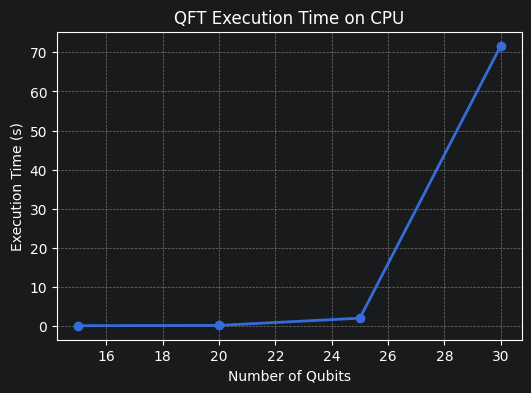

In [14]:
# Test sizes (number of qubits)
ns = [15, 20, 25, 30]

# Store execution times and results
cpu_times = []
cpu_results = []

# Ideal simulator (CPU-based)
sim = AerSimulator()

for n in ns:
    # Create quantum circuit with n qubits
    qc = QuantumCircuit(n)

    # Prepare basis state |100...0>
    qc.x(0)

    # Apply Quantum Fourier Transform
    qft(qc, n)

    # Measure all qubits
    qc.measure_all()

    # Measure execution time of simulation
    t = measure_time(qc, sim)
    cpu_times.append(t)

    # Run circuit and store normalized output distribution
    counts_cpu = run_circuit(qc, sim)
    cpu_results.append(normalize(counts_cpu))

    # Print timing result
    print(f"CPU | n={n} -> time={t:.6f}s")

# Keep only valid measurements (avoid None values if any)
valid_ns = [n for n, t in zip(ns, cpu_times) if t is not None]
valid_times = [t for t in cpu_times if t is not None]

# Plot scaling of execution time
plt.figure(figsize=(6, 4))

plt.plot(valid_ns, valid_times, marker='o', linewidth=2)

plt.xlabel("Number of Qubits")
plt.ylabel("Execution Time (s)")
plt.title("QFT Execution Time on CPU")

plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

## QPU Execution

Using backend: <IBMBackend('ibm_fez')>
QPU | n=15 -> quantum time=2.000000s | JobID=d7rkb14t738s73cfm4ng
QPU | n=20 -> quantum time=2.000000s | JobID=d7rkb34t738s73cfm4pg
QPU | n=25 -> quantum time=2.000000s | JobID=d7rkb5iudops7395qeg0
QPU | n=30 -> quantum time=2.000000s | JobID=d7rkb7iudops7395qeig


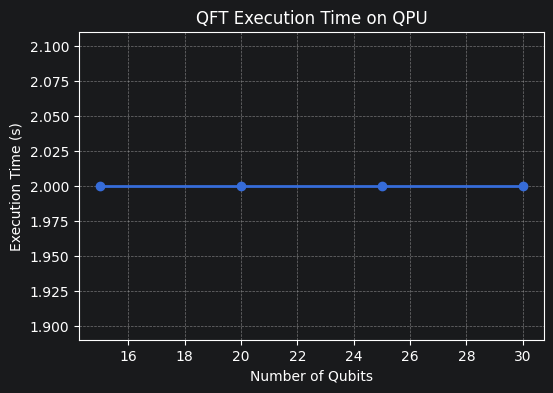

In [15]:
# Display selected IBM backend
print("Using backend:", backend)

# Store execution times and results from real hardware
qpu_times = []
qpu_results = []

for n in ns:
    # Create quantum circuit with n qubits
    qc = QuantumCircuit(n)

    # Prepare basis state |100...0>
    qc.x(0)

    # Apply Quantum Fourier Transform
    qft(qc, n)

    # Measure all qubits
    qc.measure_all()

    # Compile circuit for target backend using preset optimization
    pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
    isa_circuit = pm.run(qc)

    # Create Sampler primitive for execution on IBM Runtime
    sampler = SamplerV2(mode=backend)

    # Run job on quantum hardware
    job = sampler.run([isa_circuit], shots=1024)
    result = job.result()

    # Extract timing metadata from job result
    metadata = result[0].metadata
    qpu_time = metadata.get('execution', {}).get('running_time')

    # Fallback to runtime metrics if metadata is missing
    if qpu_time is None:
        metrics = job.metrics()
        qpu_time = metrics["usage"].get("quantum_seconds", 0)

    # Extract measurement counts
    counts_qpu = result[0].data.meas.get_counts()

    # Store results
    qpu_times.append(qpu_time)
    qpu_results.append(normalize(counts_qpu))

    # Print execution summary
    print(f"QPU | n={n} -> quantum time={qpu_time:.6f}s | JobID={job.job_id()}")

# Filter valid timing values
valid_ns = [n for n, t in zip(ns, qpu_times) if t is not None]
valid_times = [t for t in qpu_times if t is not None]

# Plot QPU scaling behavior
plt.figure(figsize=(6, 4))

plt.plot(valid_ns, valid_times, marker='o', linewidth=2)

plt.xlabel("Number of Qubits")
plt.ylabel("Execution Time (s)")
plt.title("QFT Execution Time on QPU")

plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

## CPU vs QPU Comparison


--- Comparison CPU vs QPU ---
n=15 | CPU=0.066784s | QPU=2.00s | Ratio=29.95
n=20 | CPU=0.148870s | QPU=2.00s | Ratio=13.43
n=25 | CPU=1.998720s | QPU=2.00s | Ratio=1.00
n=30 | CPU=71.685774s | QPU=2.00s | Ratio=0.03

--- Distribution Comparison CPU vs QPU ---


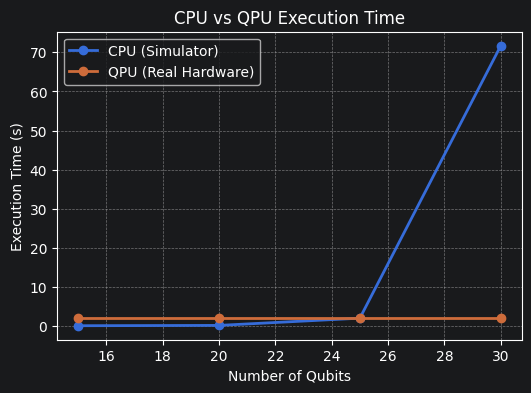

n=15 | L1 distance=0.9609
n=20 | L1 distance=0.9990
n=25 | L1 distance=1.0000
n=30 | L1 distance=1.0000


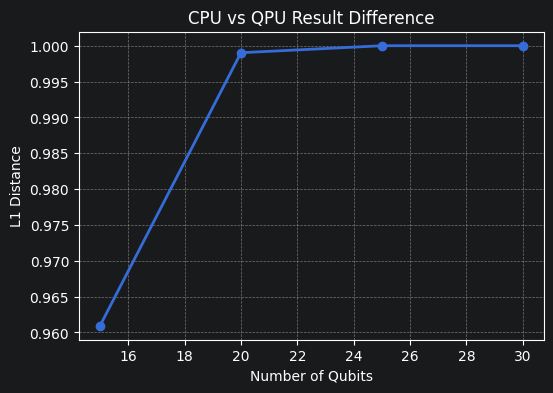

In [16]:
# Compare execution times between CPU simulator and QPU
print("\n--- Comparison CPU vs QPU ---")

for i, n in enumerate(ns):
    # Compute speed ratio (QPU / CPU)
    ratio = qpu_times[i] / cpu_times[i]

    # Print timing comparison
    print(f"n={n} | CPU={cpu_times[i]:.6f}s | QPU={qpu_times[i]:.2f}s | Ratio={ratio:.2f}")

# Plot execution time comparison
print("\n--- Distribution Comparison CPU vs QPU ---")

plt.figure(figsize=(6, 4))

plt.plot(ns, cpu_times, marker='o', linewidth=2, label="CPU (Simulator)")
plt.plot(ns, qpu_times, marker='o', linewidth=2, label="QPU (Real Hardware)")

plt.xlabel("Number of Qubits")
plt.ylabel("Execution Time (s)")
plt.title("CPU vs QPU Execution Time")

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.show()

# Compute distribution differences between CPU and QPU
errors = []

for i, n in enumerate(ns):
    # L1 distance between probability distributions
    error = l1_distance(cpu_results[i], qpu_results[i])
    errors.append(error)

    # Print per-size error
    print(f"n={n} | L1 distance={error:.4f}")

# Plot distribution error scaling
plt.figure(figsize=(6, 4))

plt.plot(ns, errors, marker='o', linewidth=2)

plt.xlabel("Number of Qubits")
plt.ylabel("L1 Distance")
plt.title("CPU vs QPU Result Difference")

plt.grid(True, linestyle='--', alpha=0.6)

plt.show()